<a href="https://colab.research.google.com/github/Harshithpalan/Deep-Lerning-python-experiments/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
num_words = 10000
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=num_words)

print(f"IMDb dataset loaded. Number of training samples: {len(train_data)}, Number of test samples: {len(test_data)}")
print(f"Number of training labels: {len(train_labels)}, Number of test labels: {len(test_labels)}")
print(f"First training review (truncated): {train_data[0][:10]}...")
print(f"First training label: {train_labels[0]}")


IMDb dataset loaded. Number of training samples: 25000, Number of test samples: 25000
Number of training labels: 25000, Number of test labels: 25000
First training review (truncated): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]...
First training label: 1


In [ ]:
## Preprocess Text Data
maxlen = 256

train_data_padded = pad_sequences(train_data, maxlen=maxlen)
test_data_padded = pad_sequences(test_data, maxlen=maxlen)

print(f"Shape of padded training data: {train_data_padded.shape}")
print(f"Shape of padded testing data: {test_data_padded.shape}")

Shape of padded training data: (25000, 256)
Shape of padded testing data: (25000, 256)


In [ ]:
embedding_dim = 128

model = Sequential()
model.add(Embedding(input_dim=num_words, output_dim=embedding_dim)) # Removed input_length
model.add(LSTM(units=128))
model.add(Dense(units=1, activation='sigmoid'))

# Explicitly build the model before summary
model.build(input_shape=(None, maxlen))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("RNN Model created and compiled successfully.")
model.summary()


RNN Model created and compiled successfully.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 256, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411,713 (5.39 MB)

 Trainable params: 1,411,713 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
## Train RNN Model
epochs = 6
batch_size = 32

history = model.fit(train_data_padded, train_labels, epochs=epochs, batch_size=batch_size, validation_split=0.2)

print("Model training completed.")

Epoch 1/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 170s 271ms/step - accuracy: 0.7814 - loss: 0.4612 - val_accuracy: 0.8260 - val_loss: 0.3898
Epoch 2/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 178s 285ms/step - accuracy: 0.8799 - loss: 0.2974 - val_accuracy: 0.8526 - val_loss: 0.3395
Epoch 3/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 191s 267ms/step - accuracy: 0.9248 - loss: 0.1998 - val_accuracy: 0.8508 - val_loss: 0.3566
Epoch 4/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 175s 280ms/step - accuracy: 0.9489 - loss: 0.1403 - val_accuracy: 0.8492 - val_loss: 0.4205
Epoch 5/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 178s 284ms/step - accuracy: 0.9664 - loss: 0.0942 - val_accuracy: 0.8636 - val_loss: 0.4910
Epoch 6/6
625/625 ━━━━━━━━━━━━━━━━━━━━ 176s 281ms/step - accuracy: 0.9706 - loss: 0.0879 - val_accuracy: 0.8594 - val_loss: 0.5203
Model training completed.


In [ ]:
## Evaluate RNN Model

y_pred_proba = model.predict(test_data_padded)
y_pred_classes = (y_pred_proba > 0.5).astype('int32')

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy = accuracy_score(test_labels, y_pred_classes)
precision = precision_score(test_labels, y_pred_classes)
recall = recall_score(test_labels, y_pred_classes)
f1 = f1_score(test_labels, y_pred_classes)
conf_matrix = confusion_matrix(test_labels, y_pred_classes)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

782/782 ━━━━━━━━━━━━━━━━━━━━ 56s 72ms/step
Accuracy: 0.8570
Precision: 0.8544
Recall: 0.8606
F1-Score: 0.8575
Confusion Matrix:
[[10667  1833]
 [ 1743 10757]]


Metric Names: ['Accuracy', 'Precision', 'Recall']
Metric Values: ['0.8570', '0.8544', '0.8606']


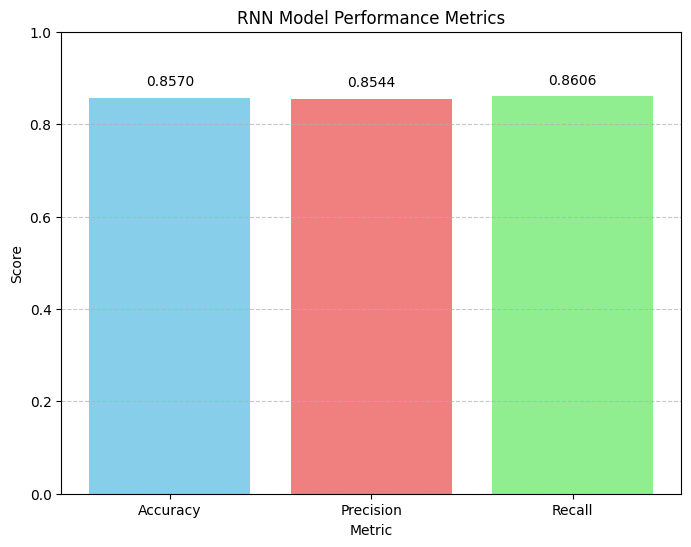

Bar chart of model performance metrics displayed.


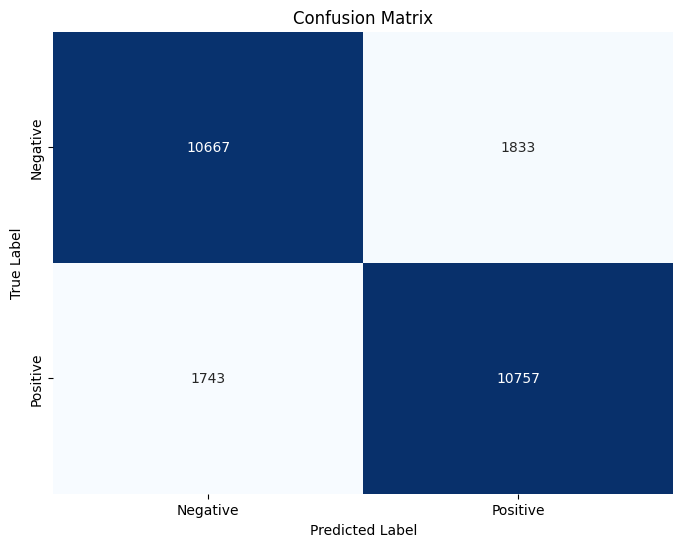

Confusion matrix heatmap displayed successfully.


In [ ]:
## Prepare Metrics Data

metric_names = ['Accuracy', 'Precision', 'Recall']
metric_values = [accuracy, precision, recall]

print(f"Metric Names: {metric_names}")
print(f"Metric Values: {[f'{val:.4f}' for val in metric_values]}")

plt.figure(figsize=(8, 6))
plt.bar(metric_names, metric_values, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.ylim(0, 1) # Metrics are between 0 and 1
plt.title('RNN Model Performance Metrics')
plt.xlabel('Metric')
plt.ylabel('Score')

for i, value in enumerate(metric_values):
    plt.text(i, value + 0.02, f'{value:.4f}', ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Bar chart of model performance metrics displayed.")

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

print("Confusion matrix heatmap displayed successfully.")